# Predicting Inflammatory Bowel Disease from Survey Data

*Final project for SI 670: Applied Machine Learning. Full notebook: [GitHub](https://github.com/shreya-gupta-um/IBD-NHIS-Prediction).*

Inflammatory Bowel Disease is rare enough in the general population that predicting it from survey data is fundamentally a class-imbalance problem. Using two years of National Health Interview Survey (NHIS) data, I tested how far feature selection, resampling, and ensemble methods could get a model toward flagging IBD risk from self-reported health and demographic data.

## What Separates IBD and Non-IBD Respondents?

*   **Significant Discriminators**: The comparison of percentages of '1's between `IBDSEV_A=0` and `IBDSEV_A=1` groups highlighted several variables with substantial differences, indicating their potential as strong discriminators for IBD status.
*   **Top Differentiators**: `ARTHEV_A` (Arthritis Ever), `SHTPNUEV_A` (Pneumococcal Vaccine Ever), `RX12M_A` (Any Prescription in Past 12 Months), `HLTHCOND_A` (Health Condition), and `SOCWRKLIM_A` (Social/Work Limitations) show the largest absolute percentage differences, suggesting they are particularly relevant in distinguishing between individuals with and without IBD.
*   **Health Conditions and Healthcare Utilization**: Many of the top differentiating variables are related to chronic health conditions (e.g., `ARTHEV_A`, `DEPEV_A`, `ANXEV_A`, `HYPEV_A`), healthcare utilization (e.g., `RX12M_A`, `MEDRXTRT_A`), and functional limitations (`SOCWRKLIM_A`, `DISAB3_A`). This aligns with the understanding that IBD can be associated with various comorbidities and impact daily life.
*   **Employment-Related Variables**: Features related to employment status and benefits (`EMPWRKLSW1_A`, `EMPLASTWK_A`, `EMPWRKFT1_A`, `EMPSICKLV_A`, `EMPHEALINS_A`) also show notable differences, which could reflect the impact of chronic illness on work life.

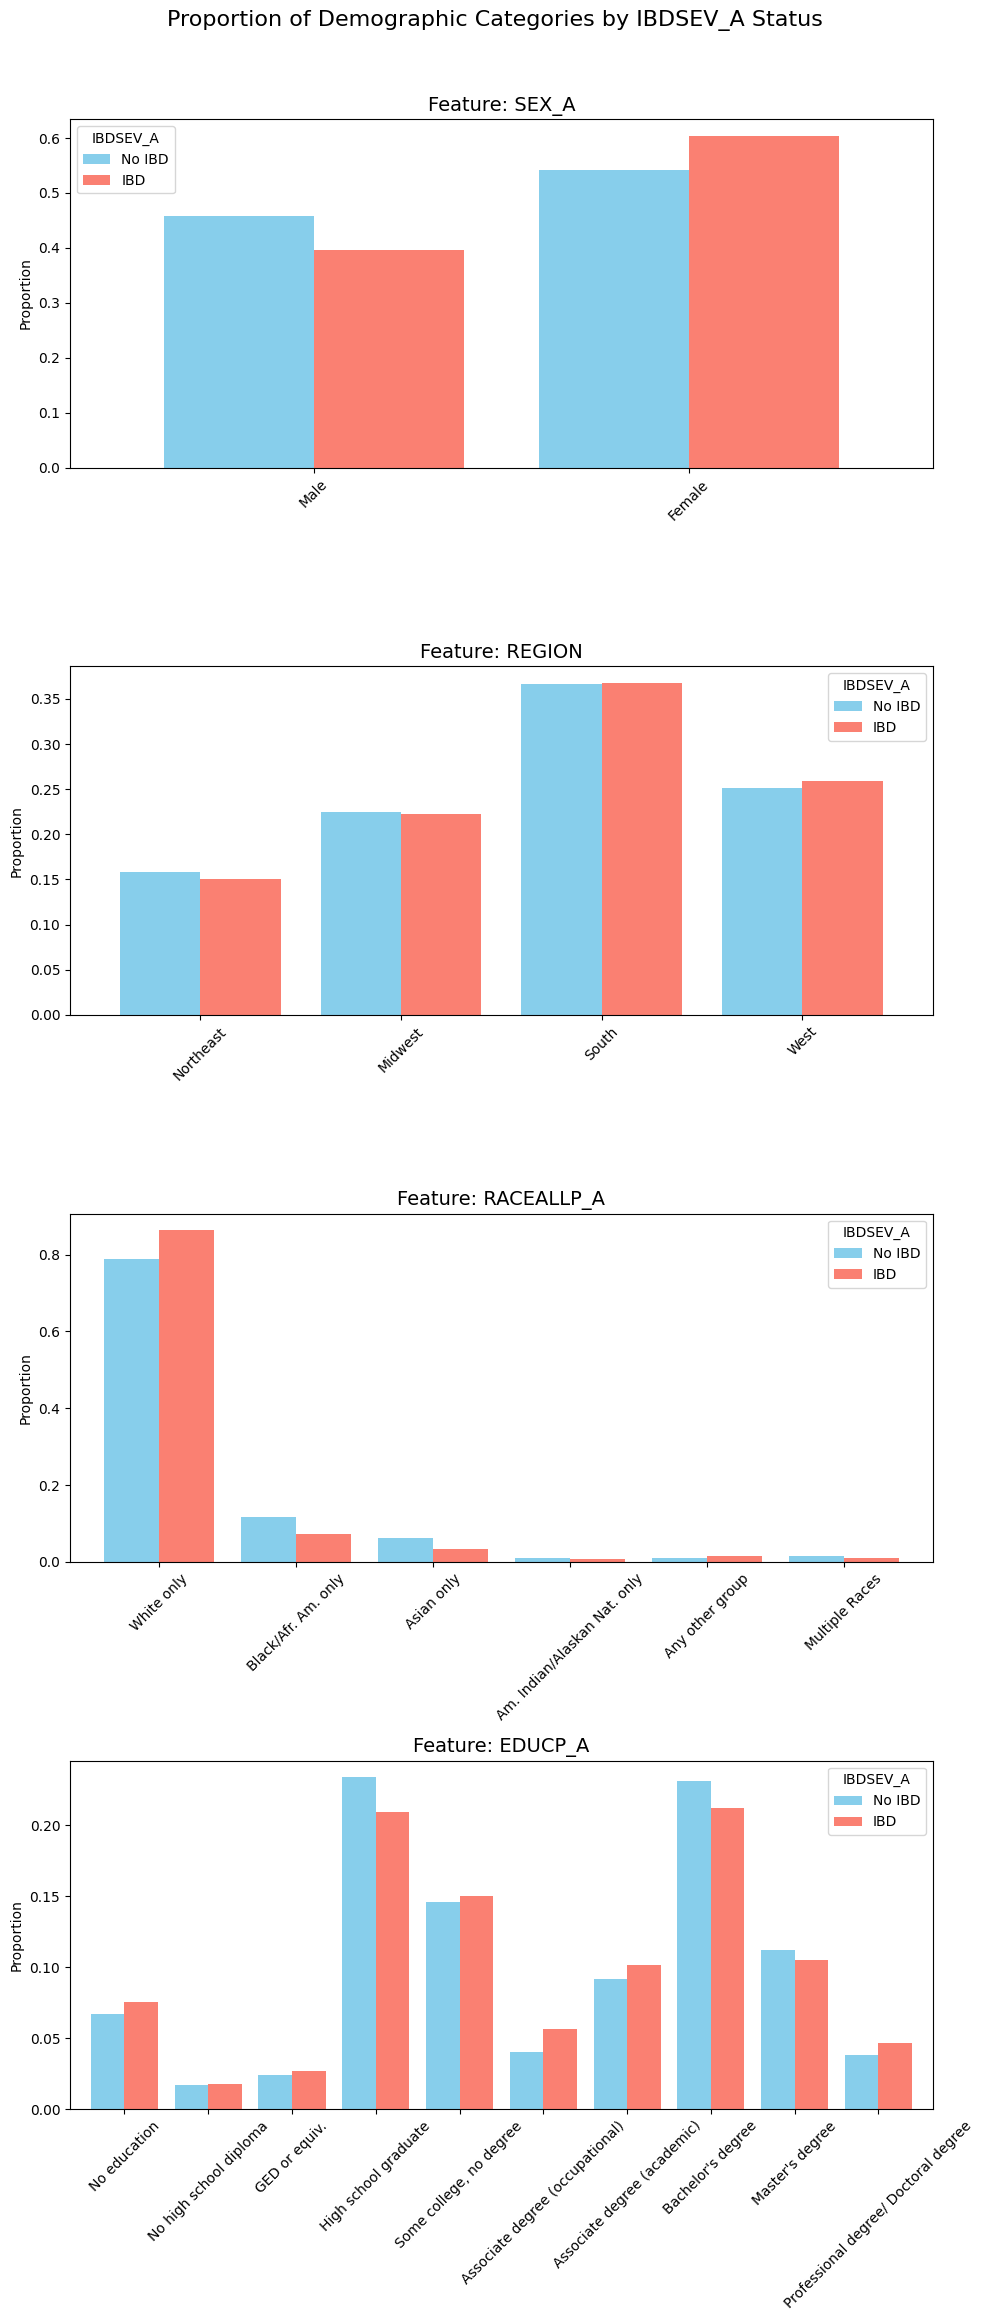

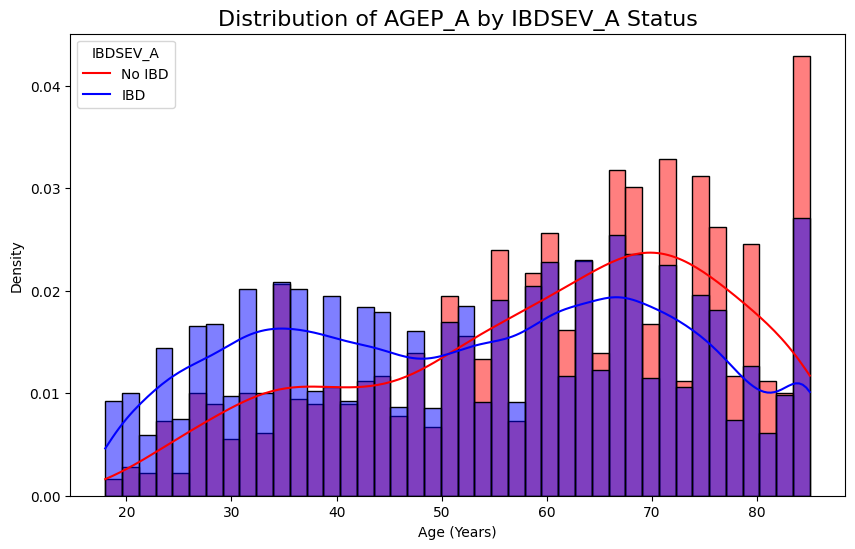

In [15]:
# Define categorical and numerical columns for plotting
categorical_cols_for_plot = ['SEX_A', 'REGION', 'RACEALLP_A', 'EDUCP_A']
numerical_col_for_plot = 'AGEP_A'
target_col = 'IBDSEV_A'

# Map numerical codes to more descriptive labels for categorical plots for better readability
sex_mapping = {1: 'Male', 2: 'Female'}
region_mapping = {1: 'Northeast', 2: 'Midwest', 3: 'South', 4: 'West'}
race_mapping = {
    1: 'White only',
    2: 'Black/Afr. Am. only',
    3: 'Asian only',
    4: 'Am. Indian/Alaskan Nat. only',
    5: 'Any other group',
    6: 'Multiple Races'
}
educ_mapping = {
    1: 'No education',
    2: 'No high school diploma',
    3: 'GED or equiv.',
    4: 'High school graduate',
    5: 'Some college, no degree',
    6: 'Associate degree (occupational)',
    7: 'Associate degree (academic)',
    8: 'Bachelor\'s degree',
    9: 'Master\'s degree',
    10: 'Professional degree/ Doctoral degree'
}

# Prepare figure for categorical plots
fig_cat, axes_cat = plt.subplots(len(categorical_cols_for_plot), 1, figsize=(10, 6 * len(categorical_cols_for_plot)))
fig_cat.suptitle('Proportion of Demographic Categories by IBDSEV_A Status', fontsize=16, y=0.995)

for i, col in enumerate(categorical_cols_for_plot):
    # Calculate proportions for each category within IBDSEV_A=0 and IBDSEV_A=1
    proportions = demographic_df.groupby(target_col)[col].value_counts(normalize=True).unstack(target_col)

    # Sort columns by index for consistent plotting, fill NaN with 0
    proportions = proportions.fillna(0)

    # Apply mapping for labels if available
    if col == 'SEX_A':
        proportions.rename(index=sex_mapping, inplace=True)
    elif col == 'REGION':
        proportions.rename(index=region_mapping, inplace=True)
    elif col == 'RACEALLP_A':
        proportions.rename(index=race_mapping, inplace=True)
    elif col == 'EDUCP_A':
        proportions.rename(index=educ_mapping, inplace=True)

    proportions.plot(kind='bar', ax=axes_cat[i], width=0.8, color=['skyblue', 'salmon'])
    axes_cat[i].set_title(f'Feature: {col}', fontsize=14)
    axes_cat[i].set_xlabel('') # Remove redundant x-axis label
    axes_cat[i].set_ylabel('Proportion')
    axes_cat[i].tick_params(axis='x', rotation=45)
    axes_cat[i].legend(title=target_col, labels=['No IBD', 'IBD'])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Create a histogram/density plot for AGEP_A
plt.figure(figsize=(10, 6))
sns.histplot(data=demographic_df, x=numerical_col_for_plot, hue=target_col, kde=True, stat='density', common_norm=False, palette={0: 'blue', 1: 'red'})
plt.title('Distribution of AGEP_A by IBDSEV_A Status', fontsize=16)
plt.xlabel('Age (Years)')
plt.ylabel('Density')
plt.legend(title=target_col, labels=['No IBD', 'IBD'])
plt.show()

Several features show higher prevalence among individuals with IBD, and their patterns are consistent with what is known about the disease and its broader impacts.

* **Depression** (DEPEV_A) and **Anxiety** (ANXEV_A) are more common in the IBD group, which may reflect the psychological burden of living with a chronic, unpredictable gastrointestinal condition.
* Frequent prescription use (RX12M_A) and reporting multiple health conditions (**Hypertension, Arthiritis**) likely reflect the presence of comorbidities and the need for ongoing medical management.
* Similarly, a higher incidence of **social or work limitations** (SOCWRKLIM_A) and **overnight hospital stays** (HOSPONGT_A) may indicate the functional impact of severe IBD on daily life.

Conversely, employment-related features such as EMPWRKLSW1_A (Ever Worked for Employer), EMPLASTWK_A (Worked Last Week), EMPWRKFT1_A (Worked Full-time for Employer), and INCWRKO_A (Received Income from Wages/Salary) exhibit slightly higher or comparable prevalence among individuals without IBD. **This suggests that chronic illness may impact employment or income-related activities.**

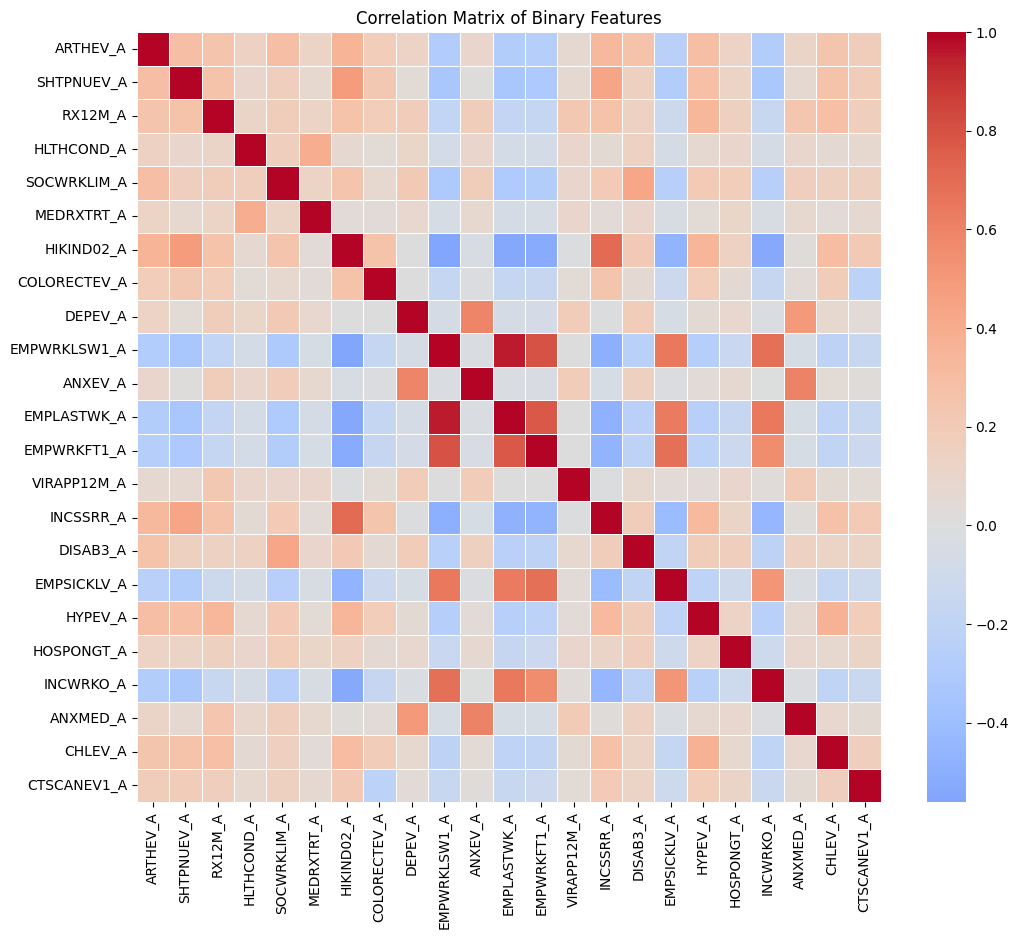

In [18]:
corr_matrix = combined_df_processed[X_features].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Matrix of Binary Features")
plt.show()

There are several noticeable clusters of dark red cells, indicating **strong positive relationships:**

* **Health-related conditions:** Features like DEPEV_A (Depression Ever) and ANXEV_A (Anxiety Ever) are strongly positively correlated, which is expected as these mental health conditions often co-occur. Similarly, HYPEV_A (Hypertension Ever) and CHLEV_A (High Cholesterol Ever) also show a strong positive correlation, reflecting common comorbidities.

* **Healthcare utilization:** HLTHCOND_A (Health Condition) and MEDRXTRT_A (Weakened immune system due to prescriptions) are highly correlated, suggesting that individuals with weakening health conditions are likely to be receiving immunosuppressive medication treatment.

* **Employment-related:** Features such as EMPWRKLSW1_A (Ever Worked for Employer), EMPLASTWK_A (Worked Last Week), and INCWRKO_A (Received Income from Wages/Salary) show strong inter-correlations, which is logical as these describe different aspects of being employed and earning income.

## Why Simple Separation Doesn't Work

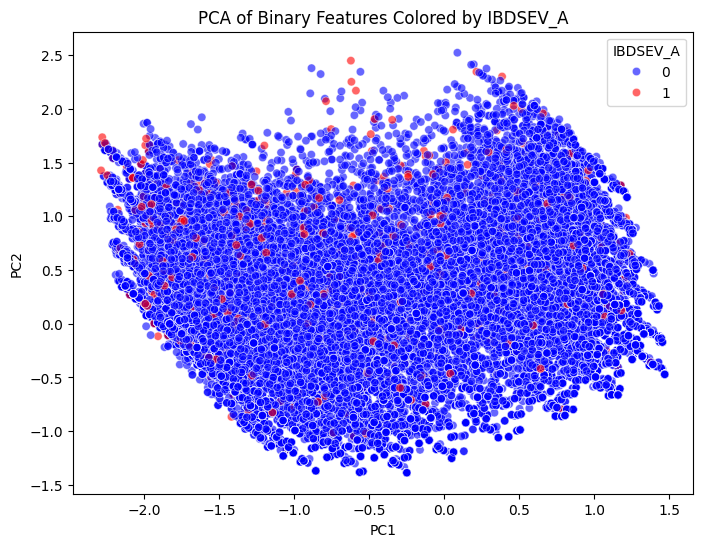

In [20]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(combined_df_processed[X_features])

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=combined_df_processed[y_target],
                palette={0:'blue', 1:'red'}, alpha=0.6)
plt.title("PCA of Binary Features Colored by IBDSEV_A")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

* **Observation of Spatial Distribution**: Upon examining the PCA plot, it is evident that the blue data points (representing `IBDSEV_A=0`) and the green data points (representing `IBDSEV_A=1`) are **heavily intermixed** throughout the 2-dimensional PCA space. There is no clear boundary or region where one class predominantly exists without significant overlap from the other.

* **Lack of Distinct Clusters**: The two classes do not form distinct, well-separated clusters. Instead, `IBDSEV_A=1` (red points) appear to be scattered widely within the larger distribution of `IBDSEV_A=0` (blue points).

* **Inference of Separability**: Based on this observation, PCA has **not effectively separated** the `IBDSEV_A` classes. The principal components, while capturing the most variance in the dataset, do not seem to project the data in a way that makes the two target classes linearly or easily non-linearly distinguishable.

*   **Challenge for Predictive Models**: The significant overlap between the two classes in the PCA-reduced space poses a considerable challenge for building effective predictive models based solely on these principal components.

Unfortunately, this means that any classifier (e.g., Logistic Regression, SVM, Decision Tree) attempting to draw a decision boundary in this space **would likely struggle to achieve high accuracy, precision, or recall for either class, especially the minority class (`IBDSEV_A=1`).**

This is not a surprise, considering the nature of using survey data to find determiners of a rare chronic condition. However, it is still worth it to explore and see what results we arrive at.

## Modeling an Imbalanced, Rare Outcome

Because IBD cases are rare, a model that predicts "no IBD" for everyone scores deceptively well on accuracy. I compared baseline, undersampled, and SMOTE-oversampled training across several classifiers (logistic regression, random forest, gradient boosting, and a stacking ensemble), evaluating on F1 rather than accuracy.

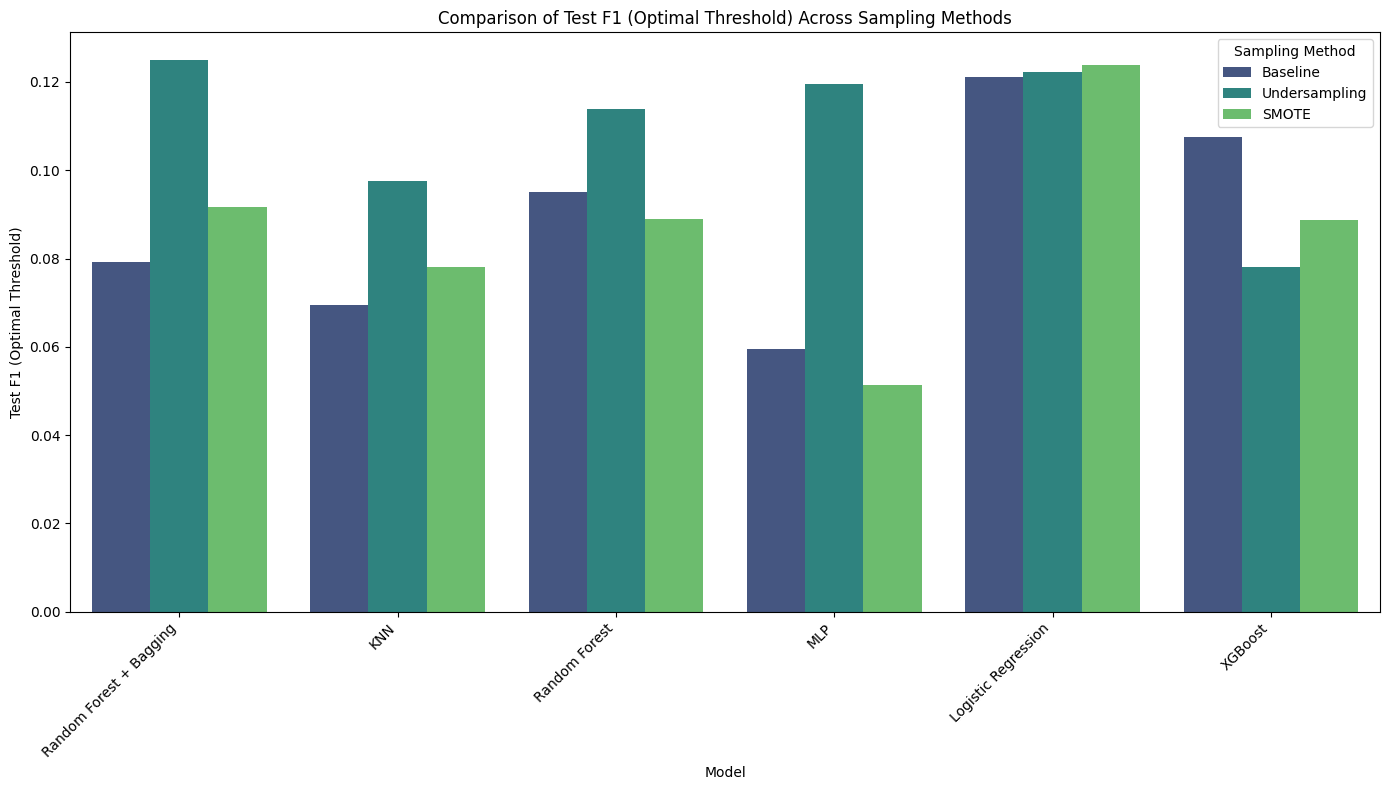

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure all results dataframes are available. If not, re-run relevant cells.
# Assuming results_none, results_under, and results_smote are already in memory.

# Add 'Sampling Method' column to each results DataFrame
results_none['Sampling Method'] = 'Baseline'
results_under['Sampling Method'] = 'Undersampling'
results_smote['Sampling Method'] = 'SMOTE'

# Concatenate all results into a single DataFrame for plotting
all_results = pd.concat([results_none, results_under, results_smote], ignore_index=True)

# Filter out Dummy Classifiers for cleaner comparison of learned models
learned_models_results = all_results[~all_results['Model'].str.contains('Dummy')].copy()

# Sort models by their best F1 score in the Undersampling regime for consistent ordering
# Use the Undersampling results as it generally showed better performance for most models
order_f1 = learned_models_results[learned_models_results['Sampling Method'] == 'Undersampling'].sort_values('Best F1 (CV)', ascending=False)['Model'].tolist()

# Plotting F1 Score
plt.figure(figsize=(14, 8))
sns.barplot(data=learned_models_results, x='Model', y='Test F1 (Optimal Threshold)', hue='Sampling Method', palette='viridis', order=order_f1)
plt.title('Comparison of Test F1 (Optimal Threshold) Across Sampling Methods')
plt.ylabel('Test F1 (Optimal Threshold)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sampling Method')
plt.tight_layout()
plt.show()
plt.savefig('f1_comparison.png')


In [48]:
import pandas as pd

# Ensure all_results DataFrame is available from previous steps
# (It contains results from baseline, undersampling, and SMOTE for ALL models, including dummies)

# Create a pivot table for Test F1 scores
f1_comparison_df = all_results.pivot_table(
    index='Model',
    columns='Sampling Method',
    values='Test F1 (Optimal Threshold)',
    aggfunc='first' # 'first' is safe here because each model/sampling method pair has one Test F1
)

# Sort the DataFrame by Test F1 under Undersampling (or any other preferred method) for better readability
f1_comparison_df_sorted = f1_comparison_df.sort_values(by='Undersampling', ascending=False)

# Round the values to 3 decimal places
f1_comparison_df_sorted = f1_comparison_df_sorted.round(3)

print("DataFrame of Test F1 Scores Across Sampling Methods (including Dummies, rounded to 3 decimal places):")
display(f1_comparison_df_sorted)

DataFrame of Test F1 Scores Across Sampling Methods (including Dummies, rounded to 3 decimal places):


Sampling Method,Baseline,SMOTE,Undersampling
Model,,,
Random Forest + Bagging,0.079,0.092,0.125
Logistic Regression,0.121,0.124,0.122
MLP,0.059,0.051,0.119
Random Forest,0.095,0.089,0.114
KNN,0.069,0.078,0.098
XGBoost,0.108,0.089,0.078
Dummy (Majority),0.033,0.033,0.033
Dummy (Stratified),0.049,0.026,0.026


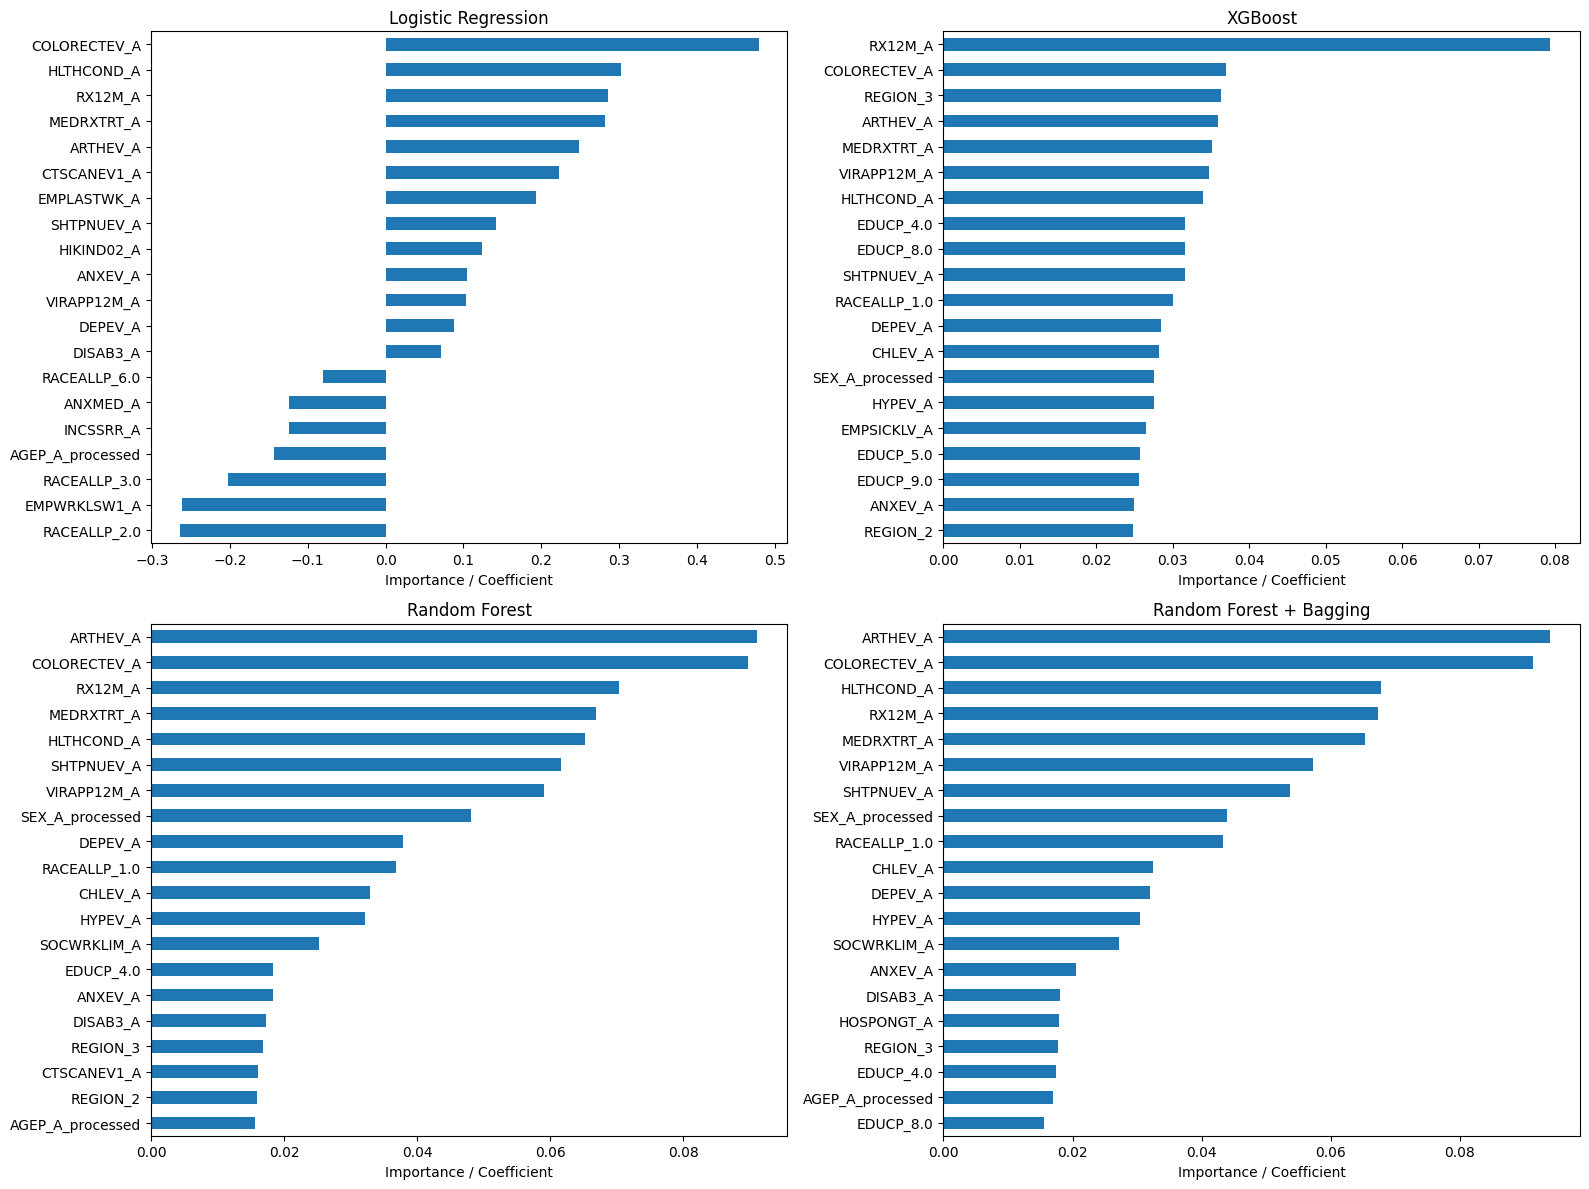

In [41]:
feature_names = X_train.columns

importances = extract_feature_importances(
    fitted_models,
    feature_names
)

plot_feature_importances(importances, top_n=20)

## Takeaway

No single model or resampling strategy fully solved the class-imbalance problem. IBD-positive respondents didn't separate cleanly in feature space (PCA showed heavy overlap between classes), and F1 scores across all approaches stayed modest. But the exercise surfaced a real, clinically sensible signal: arthritis, frequent prescription use, and mental-health comorbidities (depression, anxiety) were consistently the strongest predictors, which lines up with IBD's known pattern of overlapping chronic conditions. The bigger lesson was methodological: for rare-disease prediction, feature selection and evaluation-metric choice matter more than model choice.